# NHANES 2013-2014 EDA

Goal: Draw insights, results, and make decisions for the NHANES data preprocessing pipeline. Each section below answers one concrete question:

1. **Target balance** — class ratio for `DIQ010` (diabetes).
2. **Missingness profile** — which columns survive a 30 % missing cut.
3. **Sentinel codes** — which columns carry `7 / 9 / 77 / 99`
   "Refused / Don't know" values to recode to `NaN`.
4. **Categorical columns** — which numerics (e.g. `RIDRETH1`,
   `DMDMARTL`, `DMDEDUC2`) are really nominal/ordinal codes.
5. **Skewed body measurements** — which `BMX*` columns have
   `skew > 1` and motivate a `log1p` transform.
6. **Repeated BP readings** — whether `BPXSY1/2/3/4` and
   `BPXDI1/2/3/4` are redundant enough to collapse to a mean.
7. **Survey-design columns** — non-predictive metadata
   (`SDDSRVYR`, `SDMVPSU`, `SDMVSTRA`, `WTINT2YR`, `WTMEC2YR`) to drop.

In [3]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.data import load_nhanes, load_nhanes_raw

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
sns.set_theme(context="notebook", style="whitegrid")

In [4]:
X_raw, y = load_nhanes_raw()
X = X_raw.drop(columns=["SEQN"]).select_dtypes(include=[np.number])

print(f"raw         : X={X_raw.shape}, y={y.shape}")
print(f"raw numeric : X={X.shape}")

raw         : X=(9236, 270), y=(9236,)
raw numeric : X=(9236, 240)


## 1. Target balance

`DIQ010` was filtered to `{1 = Yes, 2 = No}` in `load_nhanes_raw`, then
recoded so `1 = diabetes`. We expect a strongly imbalanced binary target
(diabetes prevalence ~10% in the adult NHANES sample).

In [5]:
counts = y.value_counts().sort_index().rename({0: "no diabetes (DIQ010=2)", 1: "diabetes (DIQ010=1)"})
print(counts.to_string())
print(f"\npositive rate: {y.mean():.3%}  (n = {len(y):,})")

DIQ010
no diabetes (DIQ010=2)    8514
diabetes (DIQ010=1)        722

positive rate: 7.817%  (n = 9,236)


## 2. Missingness profile

We want to see (a) how the raw columns split across the missingness
spectrum, and (b) whether the 30 % cutoff we'll use in `clean_nhanes`
is reasonable or throws away useful signal. Once the cutoff is
justified, we apply it here so the downstream sections only inspect
columns that will actually survive cleaning.

numeric cols (after dropping SEQN): 240
0.100     76
0.200     97
0.300    117
0.400    119
0.500    124
0.700    175
0.900    197


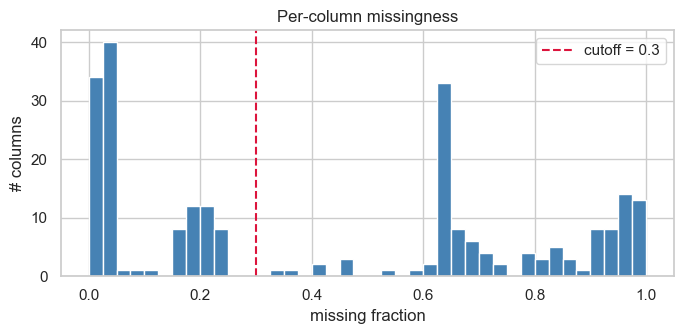

In [6]:
X_num = X_raw.drop(columns=["SEQN"]).select_dtypes(include=[np.number])
miss = X_num.isna().mean().sort_values(ascending=False)

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 0.9]
kept = pd.Series({t: int((miss <= t).sum()) for t in thresholds}, name="cols kept")
print(f"numeric cols (after dropping SEQN): {len(miss)}")
print(kept.to_string())

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(miss.values, bins=40, color="steelblue", edgecolor="white")
ax.axvline(0.3, color="crimson", linestyle="--", label="cutoff = 0.3")
ax.set_xlabel("missing fraction")
ax.set_ylabel("# columns")
ax.set_title("Per-column missingness")
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# Apply the 30% cutoff so downstream sections only see columns that will
# actually survive `clean_nhanes`. Bimodal distribution above shows almost
# nothing lives in the 30-50% band, so the threshold is well-placed.
X = X.loc[:, X.isna().mean() <= 0.30]
print(f"after 30% cutoff : X={X.shape}")

after 30% cutoff : X=(9236, 117)


## 3. Sentinel codes

NHANES question variables encode "Refused" and "Don't know" as `7/9`
(or `77/99`, `777/999`) instead of `NaN`. Median-imputing those
silently shifts the distribution, so we need to recode them in stage 2.

We scan low-cardinality numeric columns for the canonical codes, then
dump each candidate's `value_counts` so we can cross-check the NHANES
codebook. Some flagged codes are *real* categories, not sentinels
(e.g. `RIDRETH3 = 7` "Other race", `DMDFMSIZ = 7` top-coded "7 or
more") and must be left alone.

In [8]:
SENTINELS = [7, 9, 77, 99, 777, 999]

records = []
for col in X.columns:
    s = X[col]
    nunq = s.nunique(dropna=True)
    if nunq > 25:
        continue
    vmax = s.max()
    for code in SENTINELS:
        if code > vmax * 3:
            continue
        n = int((s == code).sum())
        if n > 0 and n / len(s) < 0.5:
            records.append({
                "column": col,
                "sentinel": code,
                "count": n,
                "pct": n / len(s),
                "n_unique": nunq,
                "min": s.min(),
                "max": vmax,
            })

sentinel_df = pd.DataFrame(records).sort_values(["column", "sentinel"]).reset_index(drop=True)
print(f"suspect (column, sentinel) pairs: {len(sentinel_df)}")
sentinel_df.head(25)

suspect (column, sentinel) pairs: 22


,column,sentinel,count,pct,n_unique,min,max
0,DMDBORN4,77,4,0.000,3,1.000,77.000
1,DMDCITZN,7,4,0.000,4,1.000,9.000
2,DMDCITZN,9,3,0.000,4,1.000,9.000
3,DMDFMSIZ,7,747,0.081,7,1.000,7.000
4,DMDHHSIZ,7,849,0.092,7,1.000,7.000
5,DMDHRBR4,77,12,0.001,3,1.000,77.000
6,DMDHREDU,7,9,0.001,7,1.000,9.000
7,DMDHREDU,9,12,0.001,7,1.000,9.000
8,DMDHRMAR,77,38,0.004,8,1.000,99.000
9,DMDHRMAR,99,6,0.001,8,1.000,99.000


## 4. Categorical columns

Many demographic columns are integer-coded categoricals. The generic
pipeline (median impute + standard scaler) is wrong for them — they
should be one-hot encoded (nominal) or kept as ordinal integers
(banded scales) in `preprocess_nhanes`.

Sourced from the CDC 2013-2014 Demographics variable list:

**Nominal** (one-hot encode):

- `RIAGENDR` — gender
- `RIDRETH1`, `RIDRETH3` — race / Hispanic-origin recodes
- `DMDMARTL`, `DMDHRMAR` — marital status (sample person, HH ref)
- `DMDBORN4`, `DMDHRBR4` — country of birth (sample person, HH ref)
- `DMDHRGND` — HH ref person's gender
- `DMDCITZN` — US citizenship (yes/no + refused)
- `DMQMILIZ`, `DMQADFC` — military service flags
- `RIDEXMON` — exam season (binary)
- `RIDEXPRG` — pregnancy status (only defined for women 20-44)
- `RIDSTATR` — interview-only vs. interview + exam
- `AIALANGA`, `FIALANG`, `MIALANG` — interview language
- `FIAINTRP`, `FIAPROXY`, `MIAINTRP`, `MIAPROXY` — interpreter / proxy flags

**Ordinal** (keep as integer, or one-hot if non-monotonic w.r.t. target):

- `DMDEDUC2`, `DMDEDUC3`, `DMDHREDU`, `DMDHSEDU` — education levels
- `DMDYRSUS` — length of time in the US (year bands)
- `INDFMIN2`, `INDHHIN2` — family / household income (dollar bands)

In [9]:
NOMINAL_CANDIDATES = [
    "RIAGENDR", "RIDRETH1", "RIDRETH3",
    "DMDMARTL", "DMDHRMAR",
    "DMDBORN4", "DMDHRBR4",
    "DMDHRGND", "DMDCITZN",
    "DMQMILIZ", "DMQADFC",
    "RIDEXMON", "RIDEXPRG", "RIDSTATR",
    "AIALANGA", "FIALANG", "MIALANG",
    "FIAINTRP", "FIAPROXY", "MIAINTRP", "MIAPROXY",
]
ORDINAL_CANDIDATES = [
    "DMDEDUC2", "DMDEDUC3", "DMDHREDU", "DMDHSEDU",
    "DMDYRSUS", "INDFMIN2", "INDHHIN2",
]


def summarize(cols, label):
    rows = []
    for col in cols:
        if col not in X.columns:
            rows.append({"col": col, "status": "absent (non-numeric / all-NaN)"})
            continue
        s = X[col]
        rows.append({
            "col": col,
            "miss_pct": s.isna().mean(),
            "n_unique": s.nunique(),
            "min": s.min(),
            "max": s.max(),
            "top": s.value_counts(dropna=False).idxmax(),
            "top_pct": s.value_counts(dropna=False, normalize=True).iloc[0],
        })
    print(f"\n--- {label} ---")
    print(pd.DataFrame(rows).to_string(index=False))


summarize(NOMINAL_CANDIDATES, "Nominal")
summarize(ORDINAL_CANDIDATES, "Ordinal")


--- Nominal ---
     col  miss_pct  n_unique   min    max   top  top_pct                         status
RIAGENDR     0.000     2.000 1.000  2.000 2.000    0.508                            NaN
RIDRETH1     0.000     5.000 1.000  5.000 3.000    0.360                            NaN
RIDRETH3     0.000     6.000 1.000  7.000 3.000    0.360                            NaN
DMDMARTL       NaN       NaN   NaN    NaN   NaN      NaN absent (non-numeric / all-NaN)
DMDHRMAR     0.011     8.000 1.000 99.000 1.000    0.573                            NaN
DMDBORN4     0.000     3.000 1.000 77.000 1.000    0.804                            NaN
DMDHRBR4     0.027     3.000 1.000 77.000 1.000    0.677                            NaN
DMDHRGND     0.000     2.000 1.000  2.000 1.000    0.503                            NaN
DMDCITZN     0.000     4.000 1.000  9.000 1.000    0.901                            NaN
DMQMILIZ       NaN       NaN   NaN    NaN   NaN      NaN absent (non-numeric / all-NaN)
 DMQADFC       

## 5. Skewed body measurements

Body composition columns (`BMX*`) are continuous and known to be
right-skewed. We rank them by absolute skewness and visually compare
raw vs. `log1p` transforms for the top offenders.

BMX skewness (raw):
BMXBMI      1.022
BMXSAD2     0.499
BMXSAD1     0.496
BMXWT       0.219
BMXWAIST    0.189
BMXARMC    -0.005
BMXLEG     -0.111
BMXARML    -1.090
BMXHT      -1.226


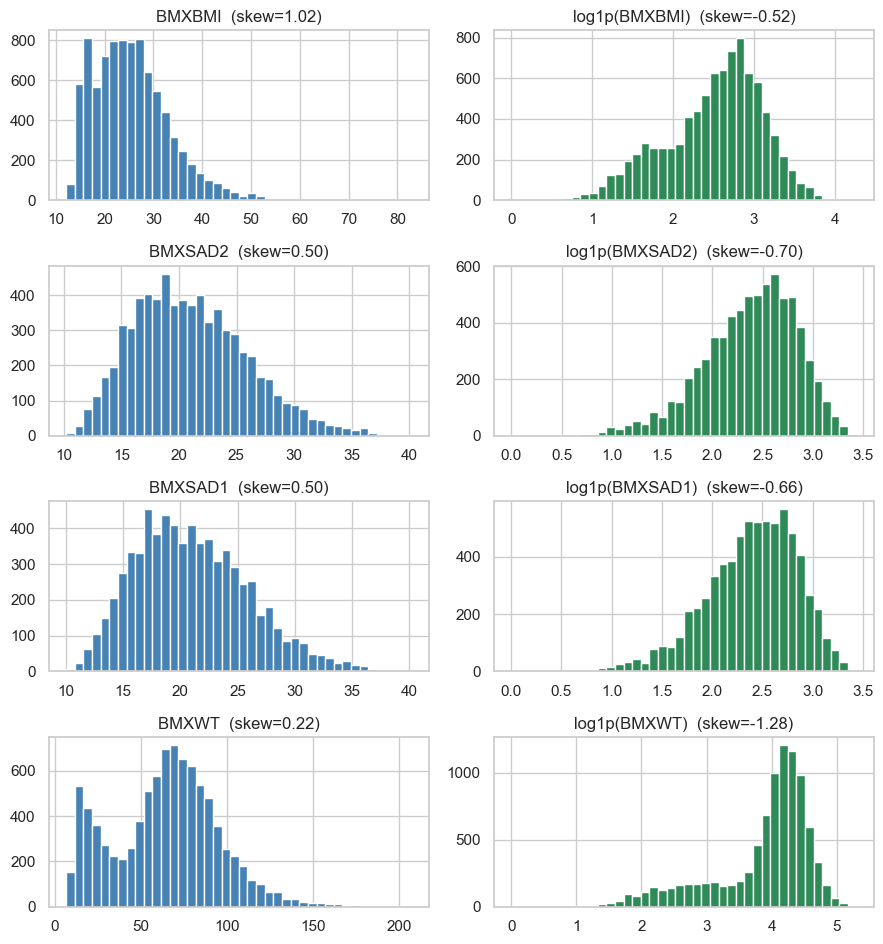

In [10]:
bmx_cols = [c for c in X.columns if c.startswith("BMX")]
skew = X[bmx_cols].skew().sort_values(ascending=False)
print("BMX skewness (raw):")
print(skew.to_string())

top = skew.head(4).index.tolist()
fig, axes = plt.subplots(len(top), 2, figsize=(9, 2.4 * len(top)))
for i, col in enumerate(top):
    s = X[col].dropna()
    axes[i, 0].hist(s, bins=40, color="steelblue", edgecolor="white")
    axes[i, 0].set_title(f"{col}  (skew={s.skew():.2f})")
    axes[i, 1].hist(np.log1p(s - s.min()), bins=40, color="seagreen", edgecolor="white")
    axes[i, 1].set_title(f"log1p({col})  (skew={np.log1p(s - s.min()).skew():.2f})")
plt.tight_layout()
plt.show()

## 6. Repeated blood-pressure readings

NHANES records up to three systolic / diastolic measurements per
participant (`BPXSY1/2/3`, `BPXDI1/2/3`). If they are highly correlated
they carry the same information and should be averaged into a single
feature.

In [11]:
bp_groups = {
    "systolic":  [c for c in ["BPXSY1", "BPXSY2", "BPXSY3", "BPXSY4"] if c in X.columns],
    "diastolic": [c for c in ["BPXDI1", "BPXDI2", "BPXDI3", "BPXDI4"] if c in X.columns],
}

for label, cols in bp_groups.items():
    if len(cols) < 2:
        print(f"{label}: <2 columns kept, skipping")
        continue
    corr = X[cols].corr()
    print(f"\n{label} correlation matrix ({cols}):")
    print(corr.round(3).to_string())


systolic correlation matrix (['BPXSY1', 'BPXSY2', 'BPXSY3']):
        BPXSY1  BPXSY2  BPXSY3
BPXSY1   1.000   0.956   0.948
BPXSY2   0.956   1.000   0.958
BPXSY3   0.948   0.958   1.000

diastolic correlation matrix (['BPXDI1', 'BPXDI2', 'BPXDI3']):
        BPXDI1  BPXDI2  BPXDI3
BPXDI1   1.000   0.842   0.823
BPXDI2   0.842   1.000   0.871
BPXDI3   0.823   0.871   1.000


## 7. Survey-design columns to drop

The CDC variable list includes a handful of columns that are *not*
predictive features — they exist to support NHANES's complex survey
design and weighted variance estimation. They are numeric and rarely
missing, so a generic numeric-only filter would keep them, but they
leak nothing about diabetes risk and (in the case of weights) can
dominate scaling. We should explicitly drop them in `clean_nhanes`:

- `SDDSRVYR` — release cycle (constant within 2013-2014, zero variance)
- `SDMVPSU`, `SDMVSTRA` — masked pseudo-PSU / pseudo-stratum
- `WTINT2YR`, `WTMEC2YR` — full-sample 2-year interview / MEC weights

In [12]:
SURVEY_DESIGN_COLS = ["SDDSRVYR", "SDMVPSU", "SDMVSTRA", "WTINT2YR", "WTMEC2YR"]

rows = []
for col in SURVEY_DESIGN_COLS:
    if col not in X.columns:
        rows.append({"col": col, "in_raw": False})
        continue
    s = X[col]
    rows.append({
        "col": col,
        "in_raw": True,
        "n_unique": s.nunique(),
        "min": s.min(),
        "max": s.max(),
        "std": s.std(),
    })

print(pd.DataFrame(rows).to_string(index=False))

     col  in_raw  n_unique       min         max        std
SDDSRVYR    True         1     8.000       8.000      0.000
 SDMVPSU    True         2     1.000       2.000      0.500
SDMVSTRA    True        15   104.000     118.000      4.259
WTINT2YR    True      6411 4,545.358 167,884.544 27,168.520
WTMEC2YR    True      7687 4,533.459 171,395.265 27,919.736


## Final Shape after stages 1 + 2: 

In [13]:
X_clean, y_clean = load_nhanes()
print(f"clean: X={X_clean.shape}, y={y_clean.shape}")
print(f"dtypes: {X_clean.dtypes.value_counts().to_dict()}")
print(f"any object dtype? {(X_clean.dtypes == object).any()}")
print(f"cols with NaN (handled by per-fold median imputation): {int(X_clean.isna().any().sum())}")

clean: X=(9236, 112), y=(9236,)
dtypes: {dtype('float64'): 96, dtype('int64'): 16}
any object dtype? False
cols with NaN (handled by per-fold median imputation): 92
